# Business Analytics Project

This notebook performs exploratory data analysis (EDA) on a synthetic project dataset and builds predictive models to estimate project success and completion time.

Run each cell sequentially to reproduce the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline

## Load the dataset

In [2]:
df = pd.read_csv('synthetic_project_dataset.csv')
df.head()

,project_id,duration_months,budget_kusd,team_size,complexity_score,stakeholder_engagement,risk_score,manager_experience_yrs,industry,success,completion_months
0,1,14.0,150.0,17,9.9,5.5,2.4,3.2,Retail,0,12.6
1,2,11.4,166.0,6,1.0,5.9,1.6,6.6,Finance,1,12.8
2,3,14.6,245.0,14,2.7,5.6,2.1,3.8,Manufacturing,1,16.8
3,4,18.1,237.0,15,4.5,6.3,3.0,4.7,Healthcare,0,18.1
4,5,11.1,199.0,4,9.4,1.3,4.1,6.2,Retail,0,12.2


## Dataset Overview

In [3]:
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())

df.describe(include='all')

Dataset shape: (300, 11)
Columns: ['project_id', 'duration_months', 'budget_kusd', 'team_size', 'complexity_score', 'stakeholder_engagement', 'risk_score', 'manager_experience_yrs', 'industry', 'success', 'completion_months']


,project_id,duration_months,budget_kusd,team_size,complexity_score,stakeholder_engagement,risk_score,manager_experience_yrs,industry,success,completion_months
count,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300,300.000000,300.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Healthcare,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72,NaN,NaN
mean,150.500000,11.98400,198.713333,11.526667,5.531000,5.465667,5.323333,4.909333,NaN,0.480000,13.127333
std,86.746758,3.84992,57.709900,5.211509,2.762337,2.423241,2.576052,1.822467,NaN,0.500435,4.274595
min,1.000000,3.00000,52.000000,3.000000,1.000000,1.000000,1.000000,1.000000,NaN,0.000000,3.000000
25%,75.750000,9.27500,157.750000,7.000000,3.000000,3.400000,3.000000,3.600000,NaN,0.000000,9.975000
50%,150.500000,12.20000,199.000000,11.500000,5.700000,5.600000,5.400000,4.900000,NaN,0.000000,13.150000
75%,225.250000,14.50000,237.000000,16.000000,8.000000,7.200000,7.625000,6.125000,NaN,1.000000,16.100000


## Distribution of Numerical Variables

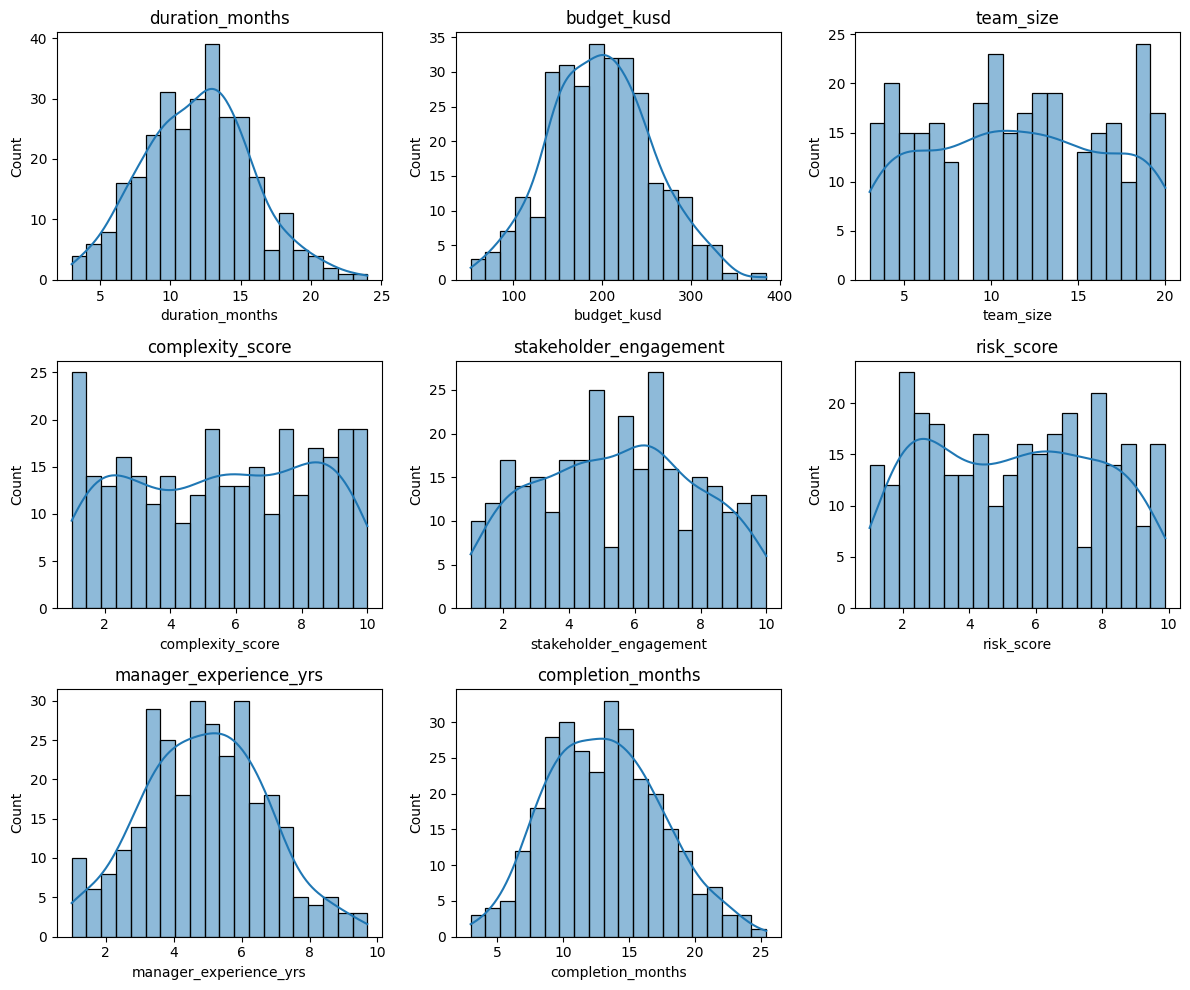

In [4]:
num_cols = ['duration_months','budget_kusd','team_size','complexity_score','stakeholder_engagement','risk_score','manager_experience_yrs','completion_months']
plt.figure(figsize=(12, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

## Correlation Heatmap

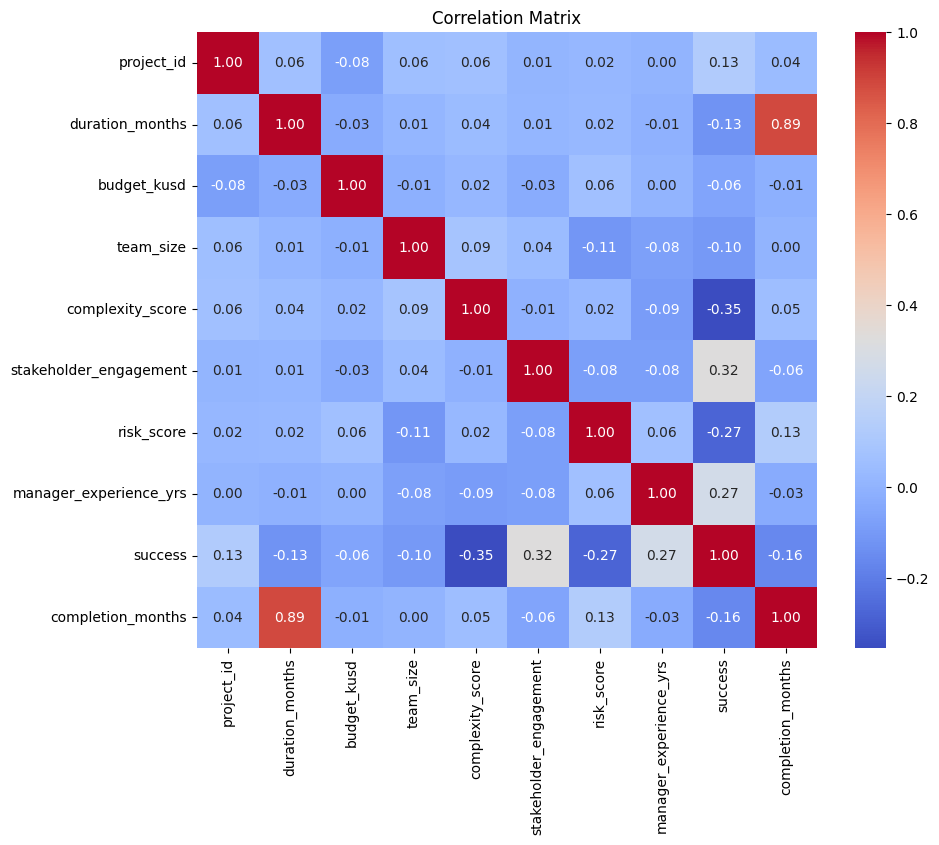

In [5]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Predicting Project Success (Classification)

In [6]:
X = df[['duration_months','budget_kusd','team_size','complexity_score','stakeholder_engagement','risk_score','manager_experience_yrs']]
y = df['success']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8111111111111111
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.71      0.78        42
           1       0.78      0.90      0.83        48

    accuracy                           0.81        90
   macro avg       0.82      0.81      0.81        90
weighted avg       0.82      0.81      0.81        90

Confusion Matrix:
[[30 12]
 [ 5 43]]


## Predicting Completion Time (Regression)

In [7]:
X_reg = df[['duration_months','budget_kusd','team_size','complexity_score','stakeholder_engagement','risk_score','manager_experience_yrs']]
y_reg = df['completion_months']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)
linreg = LinearRegression()
linreg.fit(X_train_r, y_train_r)
y_pred_r = linreg.predict(X_test_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)
print('RMSE:', rmse)
print('R-squared:', r2)

RMSE: 1.9232926376141808
R-squared: 0.7624015580656194
